# Mesa Beaver Canal Simulation - Water-Greedy Stigmergy + Hemisphere Erosion

**UPDATED5** â€” Hemisphere erosion pipeline integrated.

### Per-year pipeline:
1. Mesa runs agents on current surface â†’ agents excavate
2. New excavation accumulated into cumulative counter_dem
3. `site_counter_dem_(year).csv` â€” cumulative excavation counts
4. `site_volume_(year).csv` â€” counts â†’ hemisphere radii (saturating at r_limit)
5. `2d_erosion_(year).csv` â€” hemispheres carved into ORIGINAL DEM (summed overlaps)
6. Hydrology recalculated on 2d_erosion surface via Landlab
7. Updated DEM + hydrology passed to agents for next year

**Key design:** Original DEM is immutable. Any year's surface can be reconstructed from original DEM + that year's counter_dem.

## Cell 1 -  Simulation Parameters

In [1]:
# ========================================
# SIMULATION PARAMETERS
# ========================================
from pathlib import Path

# --- Input/Output ---
CSV_PATH = r"C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\TroyVT_slopes_cropped_troy_vt.csv"

# Base directory where each *run folder* will be created.
RUNS_BASE_DIR = str(Path(CSV_PATH).parent / "runs")

# If your x/y are lon/lat, set DATA_EPSG to your projected CRS (meters).
DATA_EPSG = 26913  # <-- CHANGE ME as needed

# Optional: if you know your DEM pixel size in meters, set it here; otherwise inferred.
GRID_SPACING_M = None  # e.g., 1.0

# --- Temporal ---
N_YEARS = 10
TICKS_PER_YEAR = 365

# --- Agents ---
N_AGENTS = 10
VISION_MIN = 3
VISION_MAX = 20
AGENT_SPEED = 3

# --- Excavation ---
EXCAVATION_DEPTH_M = 0.05

# --- Water recession ---
RECESSION_RATE = 1.0  # lower (0.1-1.0) => slower recession

# --- Hemisphere Erosion (NEW) ---
R_LIMIT = 0.75  # Asymptotic max canal half-width (meters), from field data
# Set to ~50% of measured stream half-width at your site:
#   Acadia (stream 2.5-3m):   R_LIMIT = 0.75
#   Larger site (stream 5-6m): R_LIMIT = 1.5
#   No saturation:             R_LIMIT = None

# --- Debug / visualization ---
TRACK_MOVEMENT = True
PLOT_END_OF_YEAR = True

## Cell 2 - Imports

In [2]:
# Core scientific computing
import numpy as np
import pandas as pd
import random
import math
import os
import json
import re

# Visualization
import matplotlib.pyplot as plt

# Animation (optional)
import imageio

# File management
from pathlib import Path

# Agent-based modeling
from mesa import Agent, Model

# Hydrology (Landlab yearly recompute)
from pyproj import Transformer
from landlab import RasterModelGrid
from landlab.components import FlowAccumulator

## Cell 3 - Utility Functions

In [3]:
def infer_step(vals):
    u = np.unique(np.round(np.asarray(vals, dtype=float), 6))
    u.sort()
    d = np.diff(u)
    d = d[d > 0]
    if d.size == 0:
        return np.nan
    r = np.round(d, 6)
    uniq, cnt = np.unique(r, return_counts=True)
    return float(uniq[np.argmax(cnt)])


def create_grid_FIXED(
    df: pd.DataFrame,
    grid_spacing: float = 1.0,
    x_col: str = "x",
    y_col: str = "y",
    value_cols=("elevation",),
    agg: str = "first",
    return_df_with_indices: bool = True
):
    if df.empty:
        raise ValueError("Input DataFrame is empty.")
    def _snap(v, s):
        return np.round(np.asarray(v, dtype=float) / s) * s
    x_snap = _snap(df[x_col].values, grid_spacing)
    y_snap = _snap(df[y_col].values, grid_spacing)
    x_coords = np.unique(x_snap)
    y_coords = np.unique(y_snap)
    nx, ny = len(x_coords), len(y_coords)
    x_to_ix = {x: i for i, x in enumerate(x_coords)}
    y_to_iy = {y: i for i, y in enumerate(y_coords)}
    grid = {
        "x_coords": x_coords,
        "y_coords": y_coords,
        "x_to_ix": x_to_ix,
        "y_to_iy": y_to_iy,
    }
    X, Y = np.meshgrid(x_coords, y_coords)
    grid["X"], grid["Y"] = X, Y
    work = df.copy()
    work["_x_snap"] = x_snap
    work["_y_snap"] = y_snap
    for col in value_cols:
        if col not in work.columns:
            grid[col] = np.full((ny, nx), np.nan, dtype=float)
            continue
        pv = (
            work.pivot_table(
                index="_y_snap",
                columns="_x_snap",
                values=col,
                aggfunc=agg,
                dropna=False,
            )
            .reindex(index=y_coords, columns=x_coords)
        )
        grid[col] = pv.values
    cand_cols = [c for c in value_cols if np.issubdtype(np.asarray(grid[c]).dtype, np.number)]
    if not cand_cols:
        presence = ~pd.isna(
            work.pivot_table(index="_y_snap", columns="_x_snap", values=value_cols[0], aggfunc="first")
             .reindex(index=y_coords, columns=x_coords)
             .values
        )
    else:
        stacks = [np.asarray(grid[c]) for c in cand_cols]
        presence = np.any(~np.isnan(stacks), axis=0) if len(stacks) > 1 else ~np.isnan(stacks[0])
    grid["mask"] = presence
    if return_df_with_indices:
        work["ix"] = [x_to_ix[x] for x in work["_x_snap"]]
        work["iy"] = [y_to_iy[y] for y in work["_y_snap"]]
        return grid, work.drop(columns=["_x_snap", "_y_snap"])
    return grid

## Cell 4 â€” Hydrology Recompute (Landlab)

In [4]:
def recompute_hydro_fields_landlab(
    df_in: pd.DataFrame,
    data_epsg: int,
    grid_spacing_m: float | None = None,
    agg: str = "mean",
    width_depth_fn=None,
) -> pd.DataFrame:
    df_out = df_in.copy()
    for c in ["x", "y", "elevation"]:
        if c not in df_out.columns:
            raise ValueError(f"Missing required column: {c}")
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")
    df_valid = df_out.dropna(subset=["x", "y", "elevation"]).copy()
    if df_valid.empty:
        raise ValueError("No valid rows with numeric x,y,elevation to recompute hydrology.")
    xmn, xmx = float(df_valid["x"].min()), float(df_valid["x"].max())
    ymn, ymx = float(df_valid["y"].min()), float(df_valid["y"].max())
    is_lonlat = (abs(xmn) <= 180 and abs(xmx) <= 180 and abs(ymn) <= 90 and abs(ymx) <= 90)
    if is_lonlat:
        tf = Transformer.from_crs("EPSG:4326", f"EPSG:{data_epsg}", always_xy=True)
        X, Y = tf.transform(df_valid["x"].to_numpy(), df_valid["y"].to_numpy())
        df_valid["x"] = X
        df_valid["y"] = Y
        df_out.loc[df_valid.index, "x"] = X
        df_out.loc[df_valid.index, "y"] = Y
    if grid_spacing_m is None:
        dx_x = infer_step(df_valid["x"].values)
        dx_y = infer_step(df_valid["y"].values)
        grid_spacing_m = np.nanmin([dx_x, dx_y])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0
    grid_dict, df_ixiy = create_grid_FIXED(
        df_valid,
        grid_spacing=grid_spacing_m,
        value_cols=("elevation",),
        agg=agg,
        return_df_with_indices=True,
    )
    x_coords = grid_dict["x_coords"]
    y_coords = grid_dict["y_coords"]
    nrows, ncols = len(y_coords), len(x_coords)
    try:
        mg = RasterModelGrid((nrows, ncols), xy_spacing=grid_spacing_m)
    except TypeError:
        mg = RasterModelGrid((nrows, ncols), grid_spacing_m)
    Z2d = np.array(grid_dict["elevation"], dtype=float, copy=True, order="C")
    nan_mask = ~np.isfinite(Z2d)
    if nan_mask.any():
        mg.status_at_node[nan_mask.ravel(order="C")] = mg.BC_NODE_IS_CLOSED
        safe_min = np.nanmin(Z2d)
        Z2d = np.array(np.where(nan_mask, safe_min, Z2d), dtype=float, copy=True, order="C")
    z_nodes = np.array(Z2d.ravel(order="C"), dtype=float, copy=True)
    mg.add_field("topographic__elevation", z_nodes, at="node", clobber=True)
    mg.set_closed_boundaries_at_grid_edges(False, False, False, False)
    fa = FlowAccumulator(mg, flow_director="D8", depression_finder="DepressionFinderAndRouter")
    fa.run_one_step()
    drainage_area_m2 = mg.at_node["drainage_area"].copy()
    da2d = drainage_area_m2.reshape((nrows, ncols))
    closed2d = (mg.status_at_node.reshape((nrows, ncols)) == mg.BC_NODE_IS_CLOSED)
    da2d = np.where(closed2d, np.nan, da2d)
    dz_dy, dz_dx = np.gradient(Z2d, grid_spacing_m, grid_spacing_m)
    slope2d = np.sqrt(dz_dx**2 + dz_dy**2)
    slope2d = np.where(closed2d, np.nan, slope2d)
    ix = df_ixiy["ix"].to_numpy(dtype=int)
    iy = df_ixiy["iy"].to_numpy(dtype=int)
    df_ixiy["drainage_area_m2"] = da2d[iy, ix]
    df_ixiy["slope"] = slope2d[iy, ix]
    df_ixiy["percentile"] = pd.Series(df_ixiy["drainage_area_m2"]).rank(pct=True) * 100.0
    if "slope_degrees" in df_ixiy.columns:
        df_ixiy["slope_degrees"] = np.degrees(np.arctan(df_ixiy["slope"].to_numpy(dtype=float)))
    if callable(width_depth_fn):
        df_ixiy = width_depth_fn(df_ixiy)
    for col in ["drainage_area_m2", "slope", "percentile", "slope_degrees", "width_m", "depth_m"]:
        if col in df_ixiy.columns:
            df_out.loc[df_ixiy.index, col] = df_ixiy[col].to_numpy()
    return df_out

## Cell 5 â€” Agent Class

In [5]:
class WaterFollowingExcavationAgent(Agent):
    """Water-seeking agent that excavates wet ground and follows receding water."""

    def __init__(self, unique_id, model, excavation_depth_m=0.2, speed=3):
        super().__init__(model)
        self.unique_id = unique_id
        self.excavation_depth_m = excavation_depth_m
        self.speed = speed
        self.position = None
        self.initial_position = None
        self.last_position = None
        self.total_distance = 0.0
        self.max_distance_from_start = 0.0
        self.movement_history = []
        self.visited_mask = np.zeros(self.model.grid_shape, dtype=bool)
        self.excavated_mask = np.zeros(self.model.grid_shape, dtype=bool)
        self.energy_used = 0.0
        self.debug = False

    def log(self, msg):
        if self.debug:
            print(f"[Agent {self.unique_id}] {msg}")

    def initialize_position(self):
        stream_indices = np.argwhere(self.model.stream_mask > 0)
        valid = [tuple(idx) for idx in stream_indices
                 if self.model.traversable_grid[tuple(idx)] and
                 tuple(idx) not in self.model.agent_positions]
        if valid:
            self.position = self.random.choice(valid)
        else:
            wet_indices = np.argwhere(self.model.wet_mask > 0)
            valid = [tuple(idx) for idx in wet_indices
                     if self.model.traversable_grid[tuple(idx)] and
                     tuple(idx) not in self.model.agent_positions]
            if valid:
                self.position = self.random.choice(valid)
        self.initial_position = self.position
        self.model.agent_positions[self.position] = self.unique_id
        self.movement_history.append(self.position)
        self.visited_mask[self.position] = True
        self.log(f"Initialized at {self.position}")

    def reset_at_year_start(self):
        self.position = None
        self.last_position = None
        self.initial_position = None
        self.total_distance = 0.0
        self.max_distance_from_start = 0.0
        self.movement_history = []
        self.visited_mask.fill(False)
        self.energy_used = 0.0
        self.initialize_position()

    def step(self):
        if self.model.tick > 0 and self.model.tick % self.model.ticks_per_year == 0:
            self.reset_at_year_start()
        if self.position is None:
            self.initialize_position()
            return
        for _ in range(self.speed):
            self.last_position = self.position
            if self.last_position in self.model.agent_positions:
                del self.model.agent_positions[self.last_position]
            if self.model.wet_mask[self.position] > 0:
                if not self.excavated_mask[self.position]:
                    self.model.excavate(*self.position, self.excavation_depth_m)
                    self.excavated_mask[self.position] = True
                    self.energy_used += self.excavation_depth_m
                    self.log(f"Excavated at {self.position}")
            self.chase_nearest_water()
            self.model.agent_positions[self.position] = self.unique_id
            self.update_movement_stats()

    def chase_nearest_water(self):
        for radius in range(self.model.vision_min, self.model.vision_max):
            wet_cells = self.get_perception_area(radius=radius)
            valid = [pos for pos in wet_cells
                     if self.model.wet_mask[pos] > 0 and
                        self.model.traversable_grid[pos] and
                        not self.visited_mask[pos] and
                        pos not in self.model.agent_positions]
            if valid:
                self.position = self.random.choice(valid)
                self.log(f"Random walk to water at {self.position} (radius {radius})")
                return
        self.random_walk()

    def random_walk(self):
        for radius in range(1, 6):
            candidates = self.get_perception_area(radius=radius)
            valid = [pos for pos in candidates
                     if self.model.traversable_grid[pos] and
                        pos not in self.model.agent_positions and
                        not self.visited_mask[pos]]
            if valid:
                self.position = self.random.choice(valid)
                self.log(f"Exploratory random walk to {self.position} (radius {radius})")
                return
        neighbors = self.get_perception_area(radius=1)
        valid = [pos for pos in neighbors
                 if self.model.traversable_grid[pos] and
                    pos not in self.model.agent_positions]
        if valid:
            self.position = self.random.choice(valid)
            self.log(f"Fallback walk to visited neighbor {self.position}")

    def calculate_distance(self, pos1, pos2):
        return np.linalg.norm(np.array(pos1) - np.array(pos2))

    def update_movement_stats(self):
        if self.last_position and self.position != self.last_position:
            dist = self.calculate_distance(self.last_position, self.position)
            self.total_distance += dist
            self.energy_used += dist
        if self.initial_position:
            d = self.calculate_distance(self.initial_position, self.position)
            self.max_distance_from_start = max(self.max_distance_from_start, d)
        self.movement_history.append(self.position)
        self.visited_mask[self.position] = True

    def get_perception_area(self, radius=None):
        if radius is None:
            radius = self.model.vision_max
        i, j = self.position
        area = []
        for di in range(-radius, radius + 1):
            for dj in range(-radius, radius + 1):
                if di**2 + dj**2 <= radius**2:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < self.model.grid_shape[0] and 0 <= nj < self.model.grid_shape[1]:
                        if (ni, nj) != (i, j):
                            area.append((ni, nj))
        return area

    def get_neighbors(self, i, j):
        return self.get_perception_area(radius=1)

## Cell 6 â€” BeaverWorldModel

In [6]:
class BeaverWorldModel(Model):
    """Mesa model for beaver canal excavation with seasonal water recession.

    IMPORTANT (year-cycled hydrology):
    - This model does NOT recompute drainage internally.
    - After each simulated year, the hemisphere erosion pipeline handles
      DEM updates and hydrology recalculation externally.
    """

    def __init__(
        self,
        df_world,
        n_agents=10,
        ticks_per_year=365,
        excavation_depth_m=0.2,
        agent_speed=3,
        recession_rate=1.0,
        vision_min=3,
        vision_max=20,
        verbose=True,
        cycle_year=1,
        run_dirs=None,
        run_stem=None,
        show_plots=False,
    ):
        super().__init__()
        self.verbose = bool(verbose)
        self.cycle_year = int(cycle_year)
        self.run_dirs = run_dirs
        self.run_stem = str(run_stem) if run_stem is not None else "world"
        self.show_plots = bool(show_plots)
        self.timeseries = []
        self.df_world = df_world.copy()
        self.ticks_per_year = int(ticks_per_year)
        self.excavation_depth_m = float(excavation_depth_m)
        self.agent_speed = int(agent_speed)
        self.recession_rate = float(recession_rate)
        self.tick = 0

        self.initialize_terrain(self.df_world)

        self.excavation_grid = np.zeros_like(self.elevation_grid, dtype=float)
        if "excavation_m" in self.df_world.columns:
            self._load_excavation_from_df(self.df_world)
        self.excav_total_m = float(np.nansum(self.excavation_grid))

        self._init_drainage_threshold_bounds()

        self.wet_mask = np.zeros_like(self.elevation_grid, dtype=int)
        self.wet_fraction = 0.0
        self.current_threshold = 0.0
        self.update_wet_mask()

        self.vision_min = int(vision_min)
        self.vision_max = int(vision_max)

        self.agent_positions = {}
        self.agent_list = []
        for i in range(int(n_agents)):
            agent = WaterFollowingExcavationAgent(i, self, excavation_depth_m, speed=agent_speed)
            agent.initialize_position()
            self.agent_list.append(agent)

        if self.verbose:
            print(f"\nInitialized model: {n_agents} agents @ speed={agent_speed}, {ticks_per_year} ticks/year")
            print(f"Grid shape: {self.grid_shape}")
            print(f"Stream cells: {int(self.stream_mask.sum())}")
            print(f"Drainage max: {self.drainage_max:.3g} mÂ² | start={self.drainage_start:.3g} | end={self.drainage_end:.3g}")

    def initialize_terrain(self, df: pd.DataFrame):
        x_unique = sorted(pd.unique(df["x"]))
        y_unique = sorted(pd.unique(df["y"]))
        self.grid_shape = (len(y_unique), len(x_unique))
        x_to_j = {x: j for j, x in enumerate(x_unique)}
        y_to_i = {y: i for i, y in enumerate(y_unique)}
        self.elevation_grid = np.full(self.grid_shape, np.nan, dtype=float)
        self.drainage_grid  = np.full(self.grid_shape, np.nan, dtype=float)
        self.stream_mask    = np.zeros(self.grid_shape, dtype=int)
        self.traversable_grid = np.zeros(self.grid_shape, dtype=bool)

        def _to_bool(v):
            if pd.isna(v):
                return False
            if isinstance(v, (bool, np.bool_)):
                return bool(v)
            if isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool):
                return bool(int(v))
            s = str(v).strip().lower()
            if s in ("true", "t", "1", "yes", "y"):
                return True
            if s in ("false", "f", "0", "no", "n"):
                return False
            raise ValueError(f"Unrecognized traversable value: {v!r}")

        ii = df["y"].map(y_to_i).to_numpy(dtype=int)
        jj = df["x"].map(x_to_j).to_numpy(dtype=int)
        self.elevation_grid[ii, jj] = pd.to_numeric(df["elevation"], errors="coerce").to_numpy(dtype=float)
        self.drainage_grid[ii, jj]  = pd.to_numeric(df["drainage_area_m2"], errors="coerce").to_numpy(dtype=float)
        self.stream_mask[ii, jj]    = df["stream"].astype(int).to_numpy()
        if "traversable" in df.columns:
            trav = df["traversable"].apply(_to_bool).to_numpy(dtype=bool)
            self.traversable_grid[ii, jj] = trav
        else:
            self.traversable_grid[ii, jj] = np.isfinite(self.elevation_grid[ii, jj])
        self.traversable_grid &= np.isfinite(self.elevation_grid)
        if self.verbose:
            n_nan = int(np.isnan(self.elevation_grid).sum())
            if n_nan:
                print(f"Warning: {n_nan} NaNs in elevation grid (blocked in traversable_grid)")

    def _load_excavation_from_df(self, df: pd.DataFrame):
        if "excavation_m" not in df.columns:
            return
        x_unique = sorted(pd.unique(df["x"]))
        y_unique = sorted(pd.unique(df["y"]))
        x_to_j = {x: j for j, x in enumerate(x_unique)}
        y_to_i = {y: i for i, y in enumerate(y_unique)}
        ii = df["y"].map(y_to_i).to_numpy(dtype=int)
        jj = df["x"].map(x_to_j).to_numpy(dtype=int)
        exc = pd.to_numeric(df["excavation_m"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        self.excavation_grid[ii, jj] = exc

    def _init_drainage_threshold_bounds(self):
        d = np.asarray(self.drainage_grid, dtype=float)
        dpos = d[(d > 0) & np.isfinite(d)]
        if dpos.size == 0:
            raise ValueError("drainage_grid has no positive finite values.")
        self.drainage_max = float(np.nanmax(dpos))
        self.drainage_start = float(np.nanmin(dpos))
        self.drainage_end = 0.99 * self.drainage_max
        self.log_drainage_start = float(np.log10(self.drainage_start))
        self.log_drainage_end   = float(np.log10(self.drainage_end))

    def update_wet_mask(self):
        t_year = self.tick % self.ticks_per_year
        T = self.ticks_per_year
        log_time_factor = (np.log10(t_year + 1) / np.log10(T + 1)) * self.recession_rate
        log_threshold = self.log_drainage_start + log_time_factor * (
            self.log_drainage_end - self.log_drainage_start
        )
        threshold = 10 ** log_threshold
        wet = (self.drainage_grid >= threshold)
        wet &= self.traversable_grid
        self.wet_mask = wet.astype(int)
        self.wet_fraction = float(self.wet_mask.mean())
        self.current_threshold = float(threshold)

    def excavate(self, i, j, depth_m):
        self.excavation_grid[i, j] += float(depth_m)
        self.excav_total_m += float(depth_m)

    def step(self):
        prev_wet_count = int(self.wet_mask.sum())
        self.update_wet_mask()
        new_wet_count = int(self.wet_mask.sum())
        if self.verbose:
            print(
                f"Tick {self.tick:04d} | "
                f"Cycle Year {self.cycle_year} Day {self.tick:03d} | "
                f"Threshold: {self.current_threshold:.3g} mÂ² | "
                f"Wet: {self.wet_fraction*100:.1f}% | "
                f"Lost: {prev_wet_count - new_wet_count}"
            )
        for agent in self.agent_list:
            agent.step()
        self.timeseries.append({
            "cycle_year": self.cycle_year,
            "day": int(self.tick),
            "excav_total_m": float(self.excav_total_m),
            "wet_fraction": float(self.wet_fraction),
            "threshold_m2": float(self.current_threshold),
        })
        self.tick += 1
        if self.tick % 30 == 0 and self.verbose:
            avg_distance = float(np.mean([a.total_distance for a in self.agent_list]))
            max_from_start = float(np.mean([a.max_distance_from_start for a in self.agent_list]))
            print(
                f"  Excavated: {self.excav_total_m:.1f} m | "
                f"Avg dist: {avg_distance:.1f} | "
                f"Max dist: {max_from_start:.1f}"
            )
        if self.tick % self.ticks_per_year == 0 and PLOT_END_OF_YEAR:
            print(f"\n--- End of Cycle Year {self.cycle_year} ---")
            out_dir = None
            if isinstance(self.run_dirs, dict) and ("excavation_heatmaps" in self.run_dirs):
                out_dir = self.run_dirs["excavation_heatmaps"]
            plot_excavation_heatmap(
                self, self.cycle_year,
                out_dir=out_dir, stem=self.run_stem, show=self.show_plots,
            )

    def run_model(self, n_ticks, save_frames=False, frame_dir="frames"):
        if save_frames:
            frame_dir = Path(frame_dir)
            frame_dir.mkdir(parents=True, exist_ok=True)
            print(f"[INFO] Frame output directory: {frame_dir.resolve()}")
        for t in range(int(n_ticks)):
            self.step()
            if save_frames:
                frame_path = frame_dir / f"frame_{t:04d}.png"
                plot_model_state(self, save_path=str(frame_path), show_agents=True)

## Cell 7 â€” Export & Save Functions

In [7]:
def export_world_from_model(model, df_template: pd.DataFrame) -> pd.DataFrame:
    df_out = df_template.copy()
    x_vals = np.round(df_out["x"].to_numpy(dtype=float), 6)
    y_vals = np.round(df_out["y"].to_numpy(dtype=float), 6)
    x_unique = np.round(np.array(sorted(pd.unique(x_vals))), 6)
    y_unique = np.round(np.array(sorted(pd.unique(y_vals))), 6)
    x_to_j = {x: j for j, x in enumerate(x_unique)}
    y_to_i = {y: i for i, y in enumerate(y_unique)}
    jj = np.array([x_to_j.get(x, -1) for x in x_vals], dtype=int)
    ii = np.array([y_to_i.get(y, -1) for y in y_vals], dtype=int)
    ok = (ii >= 0) & (jj >= 0)
    base_elev = np.full(len(df_out), np.nan, dtype=float)
    exc_m     = np.full(len(df_out), 0.0, dtype=float)
    base_elev[ok] = model.elevation_grid[ii[ok], jj[ok]]
    exc_m[ok]     = model.excavation_grid[ii[ok], jj[ok]]
    df_out["excavation_m"] = np.nan_to_num(exc_m, nan=0.0)
    df_out["elevation"] = base_elev - df_out["excavation_m"].to_numpy(dtype=float)
    df_out["canal"] = (df_out["excavation_m"] > 0).astype(int)
    return df_out


def save_year_csv(df: pd.DataFrame, original_csv_path: str, out_dir: str, year: int, suffix: str = "") -> str:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    stem = Path(original_csv_path).stem
    name = f"{stem}_year{year}{suffix}.csv"
    out_path = out_dir / name
    df.to_csv(out_path, index=False)
    return str(out_path)

## Cell 8 â€” Visualization Functions

In [8]:
def plot_model_state(model, save_path=None, show_agents=True):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    effective_elev = model.elevation_grid - model.excavation_grid
    im1 = axes[0].imshow(effective_elev, cmap='terrain', origin='lower')
    axes[0].set_title(f'Elevation (modified by excavation)\nTick: {model.tick}')
    plt.colorbar(im1, ax=axes[0], label='Elevation (m)')
    drainage_log = np.log10(model.drainage_grid + 1)
    im2 = axes[1].imshow(drainage_log, cmap='Blues', origin='lower')
    stream_overlay = np.ma.masked_where(model.stream_mask == 0, model.stream_mask)
    axes[1].imshow(stream_overlay, cmap='Reds', alpha=0.5, origin='lower')
    axes[1].contour(model.wet_mask, levels=[0.5], colors='lime', linewidths=2)
    axes[1].set_title('Log Drainage (blue) + Streams (red) + Wet boundary (green)')
    plt.colorbar(im2, ax=axes[1], label='Log10(Drainage)')
    excav_display = model.excavation_grid.copy()
    excav_display[excav_display == 0] = np.nan
    im3 = axes[2].imshow(excav_display, cmap='YlOrRd', origin='lower', vmin=0)
    axes[2].set_title(f'Cumulative Excavation\nTotal: {model.excav_total_m:.1f} m')
    plt.colorbar(im3, ax=axes[2], label='Depth (m)')
    if show_agents:
        for agent in model.agent_list:
            if agent.position is not None:
                i, j = agent.position
                for ax in axes:
                    ax.plot(j, i, 'r*', markersize=10, markeredgecolor='white', markeredgewidth=1.0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


def create_gif_from_frames(frame_dir, output_path, duration_ms=100):
    frame_dir = Path(frame_dir)
    frame_paths = sorted(frame_dir.glob("frame_*.png"))
    if not frame_paths:
        print(f"No frames found in {frame_dir}")
        return
    print(f"Creating GIF from {len(frame_paths)} frames...")
    with imageio.get_writer(str(output_path), mode="I", duration=duration_ms,
                           loop=0, plugin="pillow") as writer:
        for i, fp in enumerate(frame_paths):
            if i % 50 == 0:
                print(f"  Adding frame {i}/{len(frame_paths)}...")
            writer.append_data(imageio.imread(fp))
    print(f"Saved GIF: {output_path}")


def plot_agent_trajectories(model):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(model.elevation_grid, cmap='terrain', origin='lower', alpha=0.5)
    plt.colorbar(im, ax=ax, label='Elevation (m)')
    colors = plt.cm.rainbow(np.linspace(0, 1, len(model.agent_list)))
    for agent, color in zip(model.agent_list, colors):
        if len(agent.movement_history) > 1:
            trajectory = np.array(agent.movement_history)
            ax.plot(trajectory[:, 1], trajectory[:, 0], '-', color=color,
                   alpha=0.7, linewidth=2, label=f'Agent {agent.unique_id}')
            ax.plot(trajectory[0, 1], trajectory[0, 0], 'go', markersize=10,
                   markeredgecolor='white', markeredgewidth=1.5)
            ax.plot(trajectory[-1, 1], trajectory[-1, 0], 'r*', markersize=15,
                   markeredgecolor='white', markeredgewidth=1.5)
    ax.set_title('Agent Trajectories\n(Green=Start, Red Star=End)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_excavation_heatmap(model, year, save_path=None, out_dir=None, stem="world", show=False):
    if save_path is None and out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        save_path = out_dir / f"{stem}_year{int(year):02d}_excavation_heatmap.png"
    if save_path is not None:
        save_path = Path(save_path)
    fig, ax = plt.subplots(figsize=(12, 10))
    data = np.ma.masked_where(model.excavation_grid == 0, model.excavation_grid)
    im = ax.imshow(model.elevation_grid, cmap="terrain", origin="lower", alpha=0.7)
    hm = ax.imshow(data, cmap="hot", origin="lower", alpha=0.8,
                   vmin=0, vmax=float(model.excavation_grid.max() or 1))
    plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.03, pad=0.04)
    plt.colorbar(hm, ax=ax, label="Cumulative Excavation (m)", fraction=0.03, pad=0.08)
    ax.set_title(f"Cumulative Excavation Heatmap â€” End of Cycle Year {year}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return str(save_path) if save_path is not None else None


def plot_drainage_area_figure(csv_path, grid_spacing_m=None, title=None, show_dem=False, save_path=None, show=True):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path, low_memory=False)
    needed = ["x", "y", "elevation", "drainage_area_m2"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {csv_path.name}: {missing}")
    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["x", "y", "elevation", "drainage_area_m2"]).copy()
    if grid_spacing_m is None:
        dx = infer_step(df["x"].values)
        dy = infer_step(df["y"].values)
        grid_spacing_m = np.nanmin([dx, dy])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0
    grid, _ = create_grid_FIXED(
        df, grid_spacing=grid_spacing_m,
        value_cols=("elevation", "drainage_area_m2"),
        agg="mean", return_df_with_indices=True
    )
    Z2d = np.asarray(grid["elevation"], dtype=float)
    DA2d = np.asarray(grid["drainage_area_m2"], dtype=float)
    x_coords = grid["x_coords"]
    y_coords = grid["y_coords"]
    xmin, xmax = float(np.min(x_coords)), float(np.max(x_coords))
    ymin, ymax = float(np.min(y_coords)), float(np.max(y_coords))
    cell_area = float(grid_spacing_m * grid_spacing_m)
    log_da = np.log10(DA2d + cell_area)
    vmin, vmax = np.nanpercentile(log_da, [5, 99.5])
    if title is None:
        title = f"Updated drainage_area_m2 â€” {csv_path.name}"
    if show_dem:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        ax0, ax1 = axes
        ax0.imshow(Z2d, origin="lower", extent=[xmin, xmax, ymin, ymax], cmap="terrain", aspect="auto")
        ax0.set_title("Elevation (m)")
        ax0.set_xlabel("x"); ax0.set_ylabel("y")
        im = ax1.imshow(log_da, origin="lower", extent=[xmin, xmax, ymin, ymax],
                        cmap="Blues", aspect="auto", vmin=vmin, vmax=vmax)
        ax1.set_title(title)
        ax1.set_xlabel("x"); ax1.set_ylabel("y")
        plt.colorbar(im, ax=ax1, label="log10(drainage area mÂ²)")
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))
        im = ax.imshow(log_da, origin="lower", extent=[xmin, xmax, ymin, ymax],
                       cmap="Blues", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, label="log10(drainage area mÂ²)")
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200)
        print(f"Saved drainage figure: {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return save_path if save_path is not None else None

## Cell 9 â€” Run Directory Management

In [9]:
def _sanitize_for_path(s: str) -> str:
    s = str(s)
    s = re.sub(r'[<>:"/\\|?*]', '_', s)
    s = s.replace(" ", "_")
    return s


def make_run_dirs(runs_base_dir: str, original_csv_path: str, n_years: int, n_agents: int, recession_rate: float):
    runs_base = Path(runs_base_dir)
    runs_base.mkdir(parents=True, exist_ok=True)
    stem = Path(original_csv_path).stem
    rr = f"{recession_rate:g}".replace(".", "p")
    run_name = _sanitize_for_path(f"{stem}_Y{n_years}_A{n_agents}_R{rr}")
    run_root = runs_base / run_name
    if run_root.exists():
        k = 1
        while True:
            candidate = runs_base / f"{run_name}_r{k:02d}"
            if not candidate.exists():
                run_root = candidate
                break
            k += 1
    dirs = {
        "run_root": run_root,
        "year_cycles": run_root / "year_cycles",
        "DEMs": run_root / "DEMs",
        "excavation_heatmaps": run_root / "Excavation heatmaps",
        "drainage_heatmaps": run_root / "Drainage heatmaps",
        "excavation": run_root / "Excavation",
    }
    for p in dirs.values():
        if isinstance(p, Path):
            p.mkdir(parents=True, exist_ok=True)
    return run_root, dirs


def _save_run_config(run_root: Path, original_csv_path: str, n_years: int, model_kwargs: dict, data_epsg: int, grid_spacing_m):
    cfg = {
        "original_csv_path": str(original_csv_path),
        "n_years": int(n_years),
        "model_kwargs": model_kwargs,
        "data_epsg": int(data_epsg),
        "grid_spacing_m": grid_spacing_m,
    }
    (run_root / "run_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")


def save_excavation_timeseries_plots(df_ts: pd.DataFrame, out_png: str, title: str):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(df_ts["time"], df_ts["excav_total_m"], s=8)
    ax.set_title(title)
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Cumulative excavation (m)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_dem_products(csv_path: str, out_png: str, out_npy: str | None = None, grid_spacing_m=None, title: str | None = None):
    df = pd.read_csv(csv_path, low_memory=False)
    for c in ["x", "y", "elevation"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["x", "y", "elevation"]).copy()
    if grid_spacing_m is None:
        dx = infer_step(df["x"].values)
        dy = infer_step(df["y"].values)
        grid_spacing_m = np.nanmin([dx, dy])
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0
    grid, _ = create_grid_FIXED(
        df, grid_spacing=float(grid_spacing_m), value_cols=("elevation",), agg="mean", return_df_with_indices=True
    )
    Z2d = np.asarray(grid["elevation"], dtype=float)
    x_coords = grid["x_coords"]; y_coords = grid["y_coords"]
    xmin, xmax = float(np.min(x_coords)), float(np.max(x_coords))
    ymin, ymax = float(np.min(y_coords)), float(np.max(y_coords))
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(Z2d, origin="lower", extent=[xmin, xmax, ymin, ymax], cmap="terrain", aspect="auto")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(title or f"Updated DEM â€” {Path(csv_path).name}")
    plt.colorbar(im, ax=ax, label="Elevation (m)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    if out_npy:
        np.save(out_npy, Z2d)

## Cell 10 â€” Hemisphere Erosion Pipeline (NEW)

This is the core addition. Contains:
- `compute_site_volume()` â€” counter_dem â†’ (x, y, relative_volume, radius)
- `compute_2d_erosion()` / `compute_2d_erosion_fast()` â€” carve hemispheres into original DEM
- `run_hemisphere_erosion_pipeline()` â€” full step 2+3 in one call
- `run_yearly_cycles_v2()` â€” drop-in replacement for the original run loop

In [10]:
# =============================================================================
# STEP 2: Compute site_volume from counter_dem
# =============================================================================

def compute_site_volume(
    df_counter: pd.DataFrame,
    dx: float,
    dy: float,
    r_limit: float = 0.75,
) -> pd.DataFrame:
    """
    Compute site_volume_(year).csv from the counter_dem export.

    Parameters
    ----------
    df_counter : pd.DataFrame
        Must contain: x, y, and excavation_m (cumulative relative excavation count).
    dx, dy : float
        Grid spacing in meters.
    r_limit : float
        Asymptotic maximum canal half-width from field data (meters).
        Set to ~50% of measured stream half-width at your site.
        Examples:
            Acadia (stream 2.5-3m wide):  r_limit = 0.75
            Larger site (stream 5-6m wide): r_limit = 1.5
        Set to None for no saturation (raw physical radius only).

    Returns
    -------
    pd.DataFrame with columns: x, y, relative_volume, radius
    """
    df = df_counter[["x", "y"]].copy()
    df["relative_volume"] = pd.to_numeric(
        df_counter["excavation_m"], errors="coerce"
    ).fillna(0.0).values

    v_abs = np.abs(df["relative_volume"].values.astype(float))

    with np.errstate(invalid="ignore", divide="ignore"):
        r_raw = np.sqrt((2.0 * v_abs) / (dy * dx * np.pi))
    r_raw = np.where(np.isfinite(r_raw), r_raw, 0.0)

    # Apply saturating radius if r_limit is set
    # R approaches r_limit asymptotically:
    #   Small r_raw  -> R ~ r_raw           (linear, no damping)
    #   r_raw = r_limit -> R ~ 0.63 * r_limit  (starts saturating)
    #   r_raw >> r_limit -> R -> r_limit     (asymptotic ceiling)
    if r_limit is not None and r_limit > 0:
        R = r_limit * (1.0 - np.exp(-r_raw / r_limit))
    else:
        R = r_raw.copy()

    # Zero out unexcavated cells
    R = np.where(v_abs > 0, R, 0.0)
    df["radius"] = R

    return df[["x", "y", "relative_volume", "radius"]].copy()


# =============================================================================
# STEP 3: 2D Hemisphere Erosion
# =============================================================================

def compute_2d_erosion(
    original_elev_2d: np.ndarray,
    R_grid: np.ndarray,
    dx: float,
    dy: float,
) -> np.ndarray:
    """
    Carve hemispheres into the original DEM surface.
    At each cell with R > 0, hemisphere depth = sqrt(R^2 - d^2).
    Hemispheres from adjacent cells SUM their erosion.
    """
    ny, nx = original_elev_2d.shape
    cumulative_erosion = np.zeros((ny, nx), dtype=float)
    active_cells = np.argwhere(R_grid > 0)
    if active_cells.size == 0:
        return original_elev_2d.copy()

    for idx in range(len(active_cells)):
        ci, cj = active_cells[idx]
        R = float(R_grid[ci, cj])
        if R <= 0:
            continue
        reach_i = int(np.ceil(R / dy))
        reach_j = int(np.ceil(R / dx))
        i_lo = max(0, ci - reach_i)
        i_hi = min(ny, ci + reach_i + 1)
        j_lo = max(0, cj - reach_j)
        j_hi = min(nx, cj + reach_j + 1)
        i_range = np.arange(i_lo, i_hi)
        j_range = np.arange(j_lo, j_hi)
        jj, ii = np.meshgrid(j_range, i_range)
        dist_sq = ((ii - ci) * dy)**2 + ((jj - cj) * dx)**2
        R_sq = R * R
        inside = dist_sq <= R_sq
        depth = np.zeros_like(dist_sq)
        depth[inside] = np.sqrt(R_sq - dist_sq[inside])
        cumulative_erosion[i_lo:i_hi, j_lo:j_hi] += depth

    return original_elev_2d - cumulative_erosion


def compute_2d_erosion_fast(
    original_elev_2d: np.ndarray,
    R_grid: np.ndarray,
    dx: float,
    dy: float,
) -> np.ndarray:
    """
    Faster version: bins similar R values and reuses kernels.
    Falls back to cell-by-cell for < 500 active cells.
    """
    ny, nx = original_elev_2d.shape
    cumulative_erosion = np.zeros((ny, nx), dtype=float)
    active_mask = R_grid > 0
    if not active_mask.any():
        return original_elev_2d.copy()
    active_R = R_grid[active_mask]
    n_active = int(active_mask.sum())
    if n_active < 500:
        return compute_2d_erosion(original_elev_2d, R_grid, dx, dy)

    n_bins = min(50, n_active)
    R_min, R_max_val = float(active_R.min()), float(active_R.max())
    if R_max_val == R_min:
        bin_edges = np.array([R_min - 0.001, R_max_val + 0.001])
    else:
        bin_edges = np.linspace(R_min - 0.001, R_max_val + 0.001, n_bins + 1)
    bin_indices = np.digitize(R_grid[active_mask], bin_edges) - 1
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    active_cells = np.argwhere(active_mask)

    for b in range(len(bin_centers)):
        cells_in_bin = active_cells[bin_indices == b]
        if len(cells_in_bin) == 0:
            continue
        R = float(bin_centers[b])
        if R <= 0:
            continue
        reach_i = int(np.ceil(R / dy))
        reach_j = int(np.ceil(R / dx))
        ki = np.arange(-reach_i, reach_i + 1)
        kj = np.arange(-reach_j, reach_j + 1)
        KJ, KI = np.meshgrid(kj, ki)
        dist_sq = (KI * dy)**2 + (KJ * dx)**2
        R_sq = R * R
        inside = dist_sq <= R_sq
        kernel = np.zeros_like(dist_sq)
        kernel[inside] = np.sqrt(R_sq - dist_sq[inside])
        kh, kw = kernel.shape

        for cell_idx in range(len(cells_in_bin)):
            ci, cj = cells_in_bin[cell_idx]
            oi_lo = ci - reach_i
            oj_lo = cj - reach_j
            si_lo = max(0, -oi_lo)
            sj_lo = max(0, -oj_lo)
            di_lo = max(0, oi_lo)
            dj_lo = max(0, oj_lo)
            di_hi = min(ny, oi_lo + kh)
            dj_hi = min(nx, oj_lo + kw)
            si_hi = si_lo + (di_hi - di_lo)
            sj_hi = sj_lo + (dj_hi - dj_lo)
            cumulative_erosion[di_lo:di_hi, dj_lo:dj_hi] += kernel[si_lo:si_hi, sj_lo:sj_hi]

    return original_elev_2d - cumulative_erosion


def build_R_grid_from_volume(
    df_volume: pd.DataFrame,
    x_unique: np.ndarray,
    y_unique: np.ndarray,
    grid_spacing: float = 1.0,
) -> np.ndarray:
    """Map the radius column from site_volume df onto a 2D grid.

    Snaps df_volume coordinates to the same grid spacing used by
    create_grid_FIXED, so fractional DEM coordinates match the
    snapped grid axes.
    """
    ny, nx = len(y_unique), len(x_unique)
    R_grid = np.zeros((ny, nx), dtype=float)

    # Build lookup from snapped grid coordinates
    x_to_j = {round(x, 6): j for j, x in enumerate(x_unique)}
    y_to_i = {round(y, 6): i for i, y in enumerate(y_unique)}

    # Snap df_volume coordinates to the SAME grid before lookup
    x_raw = df_volume["x"].values.astype(float)
    y_raw = df_volume["y"].values.astype(float)
    x_snapped = np.round(np.round(x_raw / grid_spacing) * grid_spacing, 6)
    y_snapped = np.round(np.round(y_raw / grid_spacing) * grid_spacing, 6)
    r_vals = df_volume["radius"].values.astype(float)

    matched = 0
    for k in range(len(df_volume)):
        j = x_to_j.get(x_snapped[k], -1)
        i = y_to_i.get(y_snapped[k], -1)
        if i >= 0 and j >= 0:
            R_grid[i, j] = r_vals[k]
            matched += 1

    n_active = int((r_vals > 0).sum())
    if matched == 0 and n_active > 0:
        print(f"WARNING: 0/{n_active} radius cells mapped to grid! Check coordinate snapping.")
    elif matched < n_active:
        print(f"  Radius mapping: {matched}/{n_active} cells placed on grid")

    return R_grid


def run_hemisphere_erosion_pipeline(
    df_raw: pd.DataFrame,
    original_elev_2d: np.ndarray,
    x_unique: np.ndarray,
    y_unique: np.ndarray,
    dx: float,
    dy: float,
    r_limit: float = 0.75,
    use_fast: bool = True,
) -> tuple:
    """
    Full pipeline: counter_dem -> site_volume -> 2d_erosion.

    Returns:
      df_volume, eroded_dem_2d, df_erosion
    """
    df_volume = compute_site_volume(df_raw, dx=dx, dy=dy, r_limit=r_limit)
    R_grid = build_R_grid_from_volume(df_volume, x_unique, y_unique, grid_spacing=dx)
    erosion_fn = compute_2d_erosion_fast if use_fast else compute_2d_erosion
    eroded_dem_2d = erosion_fn(original_elev_2d, R_grid, dx, dy)

    ny, nx = len(y_unique), len(x_unique)
    XX, YY = np.meshgrid(x_unique, y_unique)
    df_erosion = pd.DataFrame({
        "x": XX.ravel(),
        "y": YY.ravel(),
        "elevation": eroded_dem_2d.ravel(),
    })
    df_erosion = df_erosion.dropna(subset=["elevation"]).reset_index(drop=True)

    return df_volume, eroded_dem_2d, df_erosion

## Cell 11 â€” Multi-Year Run Loop (v2 with Hemisphere Erosion)

In [11]:
def run_yearly_cycles_v2(
    df0: pd.DataFrame,
    original_csv_path: str,
    runs_base_dir: str,
    n_years: int,
    model_kwargs: dict,
    data_epsg: int,
    grid_spacing_m: float | None = None,
    width_depth_fn=None,
    save_drainage_fig=True,
    save_dem_each_year=True,
    save_excavation_timeseries=True,
    r_limit: float = 0.75,
):
    """
    Multi-year simulation with hemisphere erosion pipeline.

    Key design:
      - Original DEM is stored once and never modified.
      - counter_dem accumulates agent excavation across all years.
      - site_volume converts counts -> hemisphere radii.
      - 2d_erosion carves hemispheres from original DEM (summing overlaps).
      - Hydrology recalculated on 2d_erosion surface.
      - Agents receive the 2d_erosion DEM for the next cycle.

    New outputs per year:
      - site_counter_dem_(year).csv
      - site_volume_(year).csv
      - 2d_erosion_(year).csv
    """
    n_agents = int(model_kwargs.get("n_agents", 0))
    recession_rate = float(model_kwargs.get("recession_rate", 0.0))
    run_root, run_dirs = make_run_dirs(
        runs_base_dir=runs_base_dir,
        original_csv_path=original_csv_path,
        n_years=n_years,
        n_agents=n_agents,
        recession_rate=recession_rate,
    )

    # New subdirectories
    run_dirs["site_volume"] = run_root / "site_volume"
    run_dirs["2d_erosion"] = run_root / "2d_erosion"
    for p in [run_dirs["site_volume"], run_dirs["2d_erosion"]]:
        p.mkdir(parents=True, exist_ok=True)

    print(f"\n[RUN OUTPUT] {run_root}")
    _save_run_config(run_root, original_csv_path, n_years, model_kwargs, data_epsg, grid_spacing_m)

    # ------------------------------------------------------------------
    # STORE THE ORIGINAL DEM (immutable reference)
    # ------------------------------------------------------------------
    df_original = df0.copy()

    if grid_spacing_m is None:
        dx_x = infer_step(df_original["x"].values)
        dx_y = infer_step(df_original["y"].values)
        grid_spacing_m = float(np.nanmin([dx_x, dx_y]))
        if not np.isfinite(grid_spacing_m) or grid_spacing_m <= 0:
            grid_spacing_m = 1.0

    dx = grid_spacing_m
    dy = grid_spacing_m

    grid_orig, _ = create_grid_FIXED(
        df_original,
        grid_spacing=grid_spacing_m,
        value_cols=("elevation",),
        agg="mean",
        return_df_with_indices=True,
    )
    original_elev_2d = np.asarray(grid_orig["elevation"], dtype=float)
    x_unique_grid = grid_orig["x_coords"]
    y_unique_grid = grid_orig["y_coords"]

    np.save(str(run_root / "original_dem.npy"), original_elev_2d)
    print(f"  Original DEM cached: {original_elev_2d.shape}, dx={dx}, dy={dy}")
    print(f"  r_limit = {r_limit} m (hemisphere rescaling ceiling)")

    # ------------------------------------------------------------------
    # CUMULATIVE EXCAVATION TRACKER
    # ------------------------------------------------------------------
    df_cumulative_counter = df_original.copy()
    if "excavation_m" not in df_cumulative_counter.columns:
        df_cumulative_counter["excavation_m"] = 0.0
    else:
        df_cumulative_counter["excavation_m"] = pd.to_numeric(
            df_cumulative_counter["excavation_m"], errors="coerce"
        ).fillna(0.0)

    outputs = []
    df_final = None
    all_ts = []
    df_curr = df0.copy()

    for year in range(1, n_years + 1):
        print(f"\n{'='*80}")
        print(f"  YEAR {year}/{n_years} â€” Hemisphere Erosion Pipeline")
        print(f"{'='*80}")

        # A) Run Mesa for one year
        model = BeaverWorldModel(
            df_curr,
            **model_kwargs,
            cycle_year=year,
            run_dirs=run_dirs,
            run_stem=Path(original_csv_path).stem,
            show_plots=False,
        )
        model.run_model(model.ticks_per_year, save_frames=False)

        # B) Export raw and accumulate into counter_dem
        df_this_year_raw = export_world_from_model(model, df_curr)
        this_year_exc = df_this_year_raw["excavation_m"].values.astype(float)
        prev_exc = (
            df_curr["excavation_m"].values.astype(float)
            if "excavation_m" in df_curr.columns
            else np.zeros(len(df_curr))
        )
        new_exc = np.maximum(this_year_exc - prev_exc, 0.0)
        df_cumulative_counter["excavation_m"] = (
            df_cumulative_counter["excavation_m"].values.astype(float) + new_exc
        )

        stem = Path(original_csv_path).stem
        counter_path = run_dirs["year_cycles"] / f"{stem}_site_counter_dem_year{year:02d}.csv"
        df_cumulative_counter.to_csv(counter_path, index=False)
        print(f"  site_counter_dem: {counter_path.name}")
        print(f"    Total cumulative excavation: {df_cumulative_counter['excavation_m'].sum():.2f}")

        # C) Compute site_volume
        df_volume = compute_site_volume(df_cumulative_counter, dx=dx, dy=dy, r_limit=r_limit)
        volume_path = run_dirs["site_volume"] / f"{stem}_site_volume_year{year:02d}.csv"
        df_volume.to_csv(volume_path, index=False)
        n_active = int((df_volume["radius"] > 0).sum())
        R_actual_max = float(df_volume["radius"].max())
        print(f"  site_volume: {volume_path.name}")
        print(f"    Active cells: {n_active}, r_limit achieved: {R_actual_max:.3f} m")

        # D) Compute 2d_erosion
        df_volume_full, eroded_dem_2d, df_erosion = run_hemisphere_erosion_pipeline(
            df_raw=df_cumulative_counter,
            original_elev_2d=original_elev_2d,
            x_unique=x_unique_grid,
            y_unique=y_unique_grid,
            dx=dx, dy=dy,
            r_limit=r_limit,
            use_fast=True,
        )
        erosion_csv_path = run_dirs["2d_erosion"] / f"{stem}_2d_erosion_year{year:02d}.csv"
        df_erosion.to_csv(erosion_csv_path, index=False)
        max_carve = float(np.nanmax(original_elev_2d - eroded_dem_2d))
        print(f"  2d_erosion: {erosion_csv_path.name}")
        print(f"    Max hemisphere carving depth: {max_carve:.3f} m")

        # E) Build full DataFrame for hydrology recompute
        #    df_erosion has SNAPPED coordinates (from meshgrid of grid axes).
        #    df_original has RAW coordinates. Must snap before lookup.
        df_for_hydro = df_original.copy()

        # Build lookup from snapped erosion coordinates
        erosion_elev_map = {}
        for _, row in df_erosion.iterrows():
            key = (round(float(row["x"]), 6), round(float(row["y"]), 6))
            erosion_elev_map[key] = float(row["elevation"])

        # Snap original coordinates to grid before lookup
        x_raw = df_for_hydro["x"].values.astype(float)
        y_raw = df_for_hydro["y"].values.astype(float)
        x_snapped = np.round(np.round(x_raw / dx) * dx, 6)
        y_snapped = np.round(np.round(y_raw / dy) * dy, 6)

        new_elev = np.array([
            erosion_elev_map.get((x_snapped[k], y_snapped[k]), np.nan)
            for k in range(len(df_for_hydro))
        ])
        n_mapped = int(np.isfinite(new_elev).sum())
        print(f"    Erosion -> hydro mapping: {n_mapped}/{len(df_for_hydro)} cells matched")

        orig_elev = df_for_hydro["elevation"].values.astype(float)
        df_for_hydro["elevation"] = np.where(np.isfinite(new_elev), new_elev, orig_elev)
        df_for_hydro["excavation_m"] = 0.0

        # F) Recompute hydrology on 2d_erosion surface
        df_updated = recompute_hydro_fields_landlab(
            df_for_hydro,
            data_epsg=data_epsg,
            grid_spacing_m=grid_spacing_m,
            width_depth_fn=width_depth_fn,
        )
        updated_path = save_year_csv(
            df_updated, original_csv_path,
            str(run_dirs["year_cycles"]), year, suffix=""
        )
        print(f"  Updated (hydrology on 2d_erosion): {Path(updated_path).name}")

        # G) Diagnostic products
        excav_cells = df_cumulative_counter.loc[
            df_cumulative_counter["excavation_m"] > 0
        ].copy()
        excav_cells_path = (
            run_dirs["excavation_heatmaps"]
            / f"{stem}_year{year:02d}_excavation_cells.csv"
        )
        excav_cells.to_csv(excav_cells_path, index=False)

        plot_excavation_heatmap(
            model, year,
            out_dir=run_dirs.get("excavation_heatmaps"),
            stem=stem, show=False,
        )

        if save_drainage_fig:
            fig_path = run_dirs["drainage_heatmaps"] / f"{stem}_year{year:02d}_drainage.png"
            plot_drainage_area_figure(
                updated_path,
                grid_spacing_m=grid_spacing_m,
                title=f"Updated drainage_area_m2 â€” Year {year} (on 2d_erosion DEM)",
                show_dem=False, save_path=str(fig_path), show=False,
            )

        if save_dem_each_year:
            dem_png = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.png"
            dem_npy = run_dirs["DEMs"] / f"{stem}_year{year:02d}_DEM.npy"
            save_dem_products(
                updated_path,
                out_png=str(dem_png), out_npy=str(dem_npy),
                grid_spacing_m=grid_spacing_m,
                title=f"2D Erosion DEM â€” Year {year}",
            )

        if save_excavation_timeseries and hasattr(model, "timeseries"):
            df_ts = pd.DataFrame(model.timeseries)
            df_ts["time"] = df_ts["day"].astype(int)
            ts_path = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.csv"
            df_ts.to_csv(ts_path, index=False)
            ts_png = run_dirs["excavation"] / f"{stem}_year{year:02d}_excavation_timeseries.png"
            save_excavation_timeseries_plots(df_ts, out_png=str(ts_png), title=f"Time vs Excavation â€” Year {year}")
            df_ts["time"] = (year - 1) * int(model.ticks_per_year) + df_ts["day"].astype(int)
            df_ts["cycle_year"] = year
            all_ts.append(df_ts[["cycle_year", "day", "time", "excav_total_m", "wet_fraction", "threshold_m2"]])

        # H) Prepare for next year
        outputs.append((str(counter_path), updated_path))
        df_curr = df_updated
        df_final = df_updated

        print(f"\n  [Year {year}] Pipeline complete.")
        print(f"    counter_dem:  {counter_path}")
        print(f"    site_volume:  {volume_path}")
        print(f"    2d_erosion:   {erosion_csv_path}")
        print(f"    updated DEM:  {updated_path}")

    # Overall timeseries
    if save_excavation_timeseries and all_ts:
        df_all = pd.concat(all_ts, ignore_index=True)
        all_path = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.csv"
        df_all.to_csv(all_path, index=False)
        all_png = run_dirs["excavation"] / f"{stem}_all_years_excavation_timeseries.png"
        save_excavation_timeseries_plots(df_all, out_png=str(all_png), title=f"Time vs Excavation â€” All Years (N={n_years})")

    print(f"\n{'='*80}")
    print(f"Run complete. Outputs saved under:\n{run_root}")
    print(f"{'='*80}\n")

    return outputs, df_final

## Cell 12 â€” Load Data & Run

In [12]:
# --- Optional: width/depth recalculation hook ---
# def width_depth_fn(df):
#     df = df.copy()
#     df["width_m"] = ...
#     df["depth_m"] = ...
#     return df
width_depth_fn = None

# Load input data
df_world = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded {len(df_world)} rows from {CSV_PATH}")
print(f"Columns: {list(df_world.columns)}")

# Build model kwargs
model_kwargs = dict(
    n_agents=N_AGENTS,
    ticks_per_year=TICKS_PER_YEAR,
    excavation_depth_m=EXCAVATION_DEPTH_M,
    agent_speed=AGENT_SPEED,
    recession_rate=RECESSION_RATE,
    vision_min=VISION_MIN,
    vision_max=VISION_MAX,
    verbose=True,
)

# Run the simulation with hemisphere erosion pipeline
outputs, df_final = run_yearly_cycles_v2(
    df0=df_world,
    original_csv_path=CSV_PATH,
    runs_base_dir=RUNS_BASE_DIR,
    n_years=N_YEARS,
    model_kwargs=model_kwargs,
    data_epsg=DATA_EPSG,
    grid_spacing_m=GRID_SPACING_M,
    width_depth_fn=width_depth_fn,
    r_limit=R_LIMIT,
)

print("\nAll outputs:")
for counter_path, updated_path in outputs:
    print("  COUNTER DEM:", counter_path)
    print("  UPDATED:    ", updated_path)
print("\nNew subfolders: site_volume/, 2d_erosion/")
print("Tip: check RUNS_BASE_DIR for the created run folder.")

Loaded 1481649 rows from C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\TroyVT_slopes_cropped_troy_vt.csv
Columns: ['x', 'y', 'elevation', 'drainage_area_m2', 'slope', 'width_m', 'depth_m', 'percentile', 'streamline', 'label', 'x_m', 'y_m', 'proj_epsg', 'slope_degrees', 'traversable', 'stream', 'lon', 'lat', 'naip_R', 'naip_G', 'naip_B', 'naip_NIR', 'veg_NDVI', 'veg_GNDVI', 'veg_NormG', 'veg_EVI']

[RUN OUTPUT] C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1
  Original DEM cached: (645, 577), dx=0.5, dy=0.5
  r_limit = 0.75 m (hemisphere rescaling ceiling)

  YEAR 1/10 â€” Hemisphere Erosion Pipeline

Initialized model: 10 agents @ speed=3, 365 ticks/year
Grid shape: (1288, 1153)
Stream cells: 88020
Drainage max: 5.44e+04 mÂ² | start=0.25 | end=5.39e+04
Tick 0000 | Cycle Year 1 Day 000 | Threshold: 0.25 mÂ² | Wet: 23.4% | Lost: 0
Tick 0001 | Cycle Year 1 Day 001 | Threshold: 1

## Cell 13 - Final Diagnostics: Visual Summary of Last Year

6-panel figure showing:
1. **Original DEM** â€” immutable reference surface
2. **2D Erosion DEM** â€” hemisphere-carved surface (what agents walk on)
3. **Excavation Heatmap** â€” cumulative counter_dem values
4. **Updated Drainage** â€” flow accumulation on eroded surface
5. **Relative Volume** â€” excavation volume per cell
6. **Radius Scatter** â€” hemisphere R at each (x,y), point size = R

Plotting final diagnostics for Year 10
  counter_dem:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\year_cycles\TroyVT_slopes_cropped_troy_vt_site_counter_dem_year10.csv
  site_volume:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\site_volume\TroyVT_slopes_cropped_troy_vt_site_volume_year10.csv
  2d_erosion:   C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\2d_erosion\TroyVT_slopes_cropped_troy_vt_2d_erosion_year10.csv
  updated DEM:  C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\year_cycles\TroyVT_slopes_cropped_troy_vt_year10.csv


C:\Users\jordan.kennedy\AppData\Local\Temp\ipykernel_27240\905915281.py:156: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


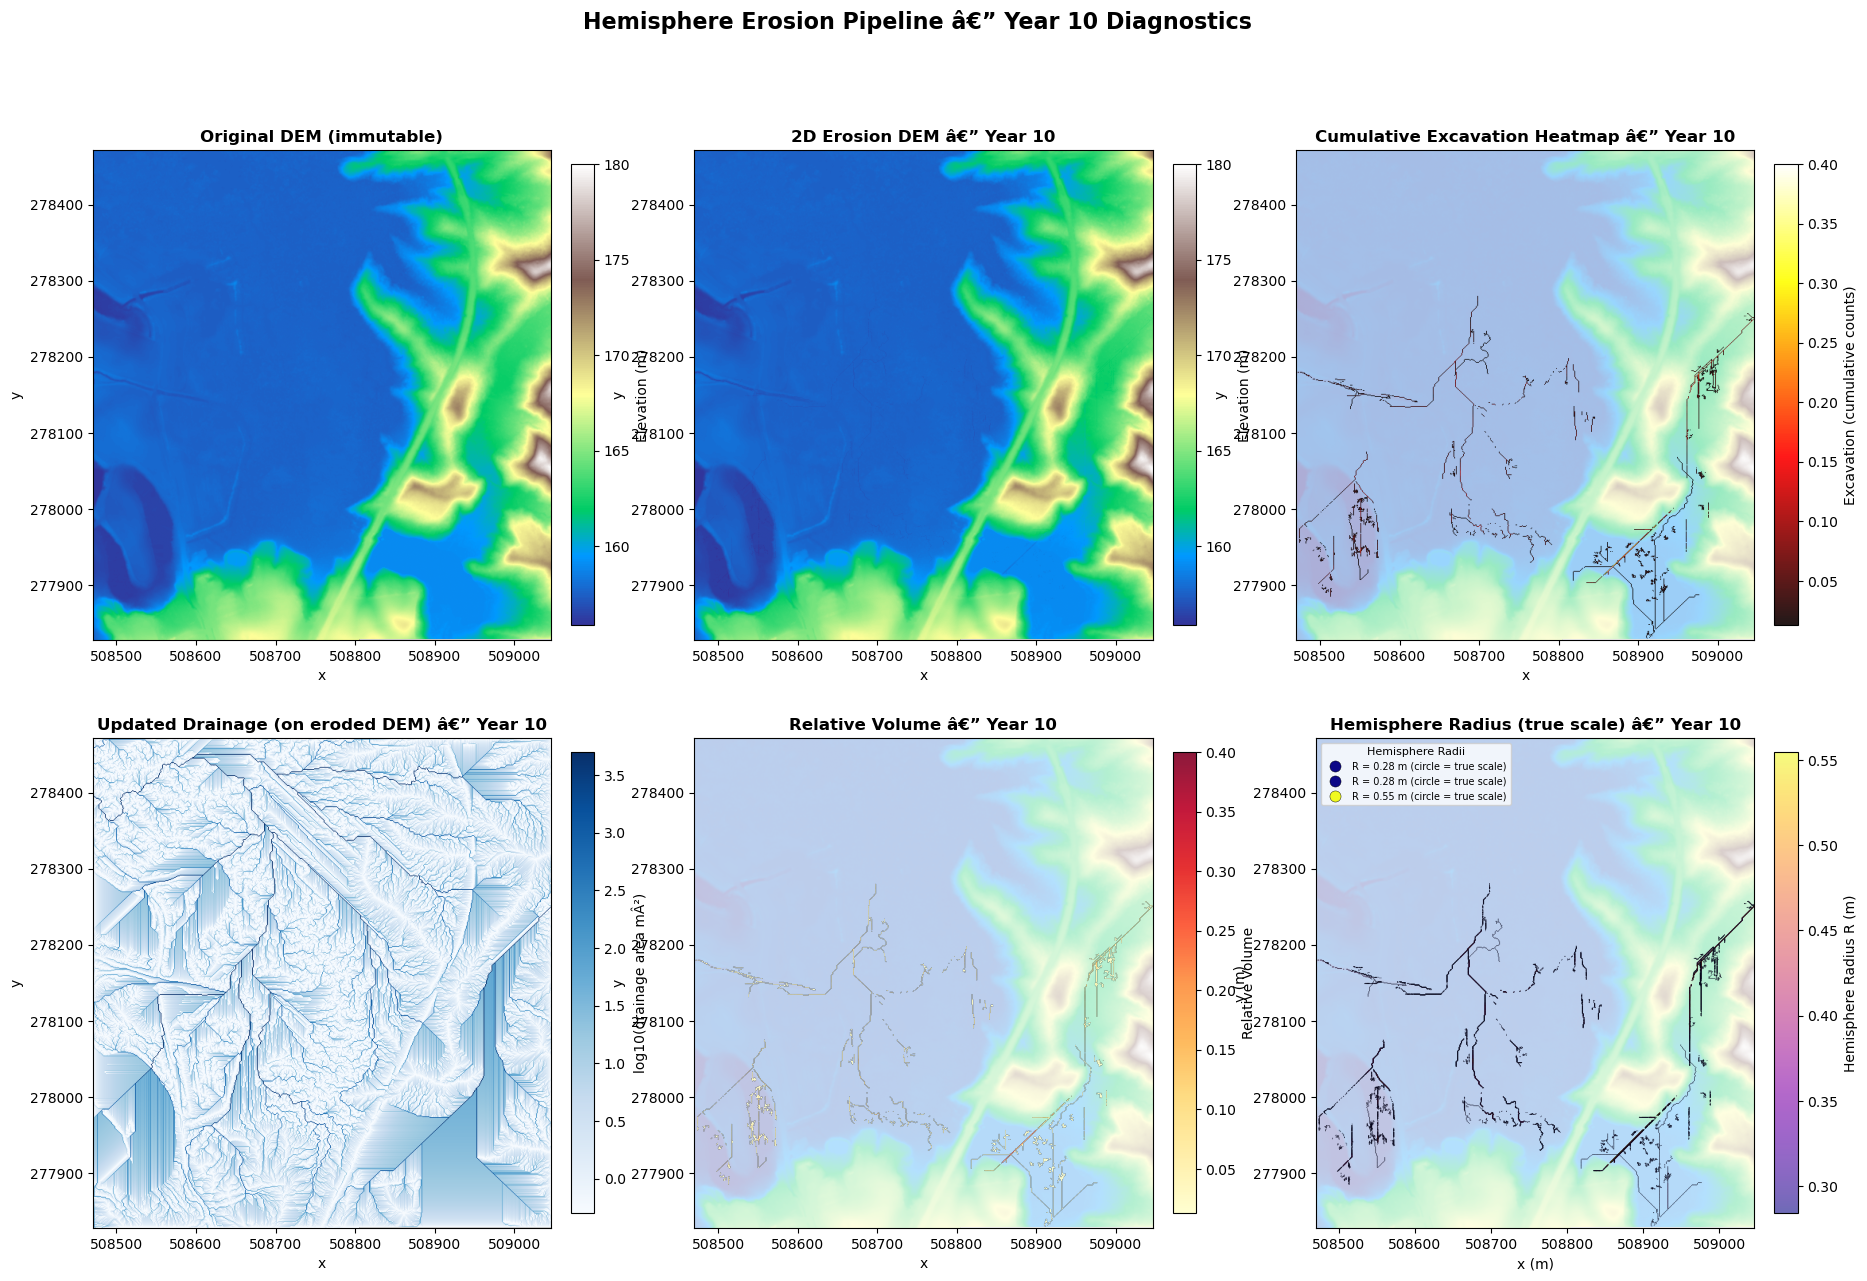

In [13]:
# ========================================================================
# FINAL VISUAL SUMMARY â€” 6-panel diagnostic figure
# ========================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path
import numpy as np
import pandas as pd

# --- Locate the last year's files ---
last_counter_path, last_updated_path = outputs[-1]
stem = Path(CSV_PATH).stem
_run_root = Path(last_counter_path).parent.parent
_last_year = N_YEARS

volume_csv = _run_root / "site_volume" / f"{stem}_site_volume_year{_last_year:02d}.csv"
erosion_csv = _run_root / "2d_erosion" / f"{stem}_2d_erosion_year{_last_year:02d}.csv"
counter_csv = Path(last_counter_path)
updated_csv = Path(last_updated_path)

print(f"Plotting final diagnostics for Year {_last_year}")
print(f"  counter_dem:  {counter_csv}")
print(f"  site_volume:  {volume_csv}")
print(f"  2d_erosion:   {erosion_csv}")
print(f"  updated DEM:  {updated_csv}")

# --- Load data ---
df_counter = pd.read_csv(counter_csv, low_memory=False)
df_volume = pd.read_csv(volume_csv, low_memory=False)
df_erosion = pd.read_csv(erosion_csv, low_memory=False)
df_updated = pd.read_csv(updated_csv, low_memory=False)
df_orig = pd.read_csv(CSV_PATH, low_memory=False)

for _df in [df_counter, df_volume, df_erosion, df_updated, df_orig]:
    for c in ["x", "y"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")
    for c in ["elevation", "excavation_m", "drainage_area_m2", "relative_volume", "radius"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")

# Infer grid spacing
_dx = infer_step(df_orig["x"].values)
_dy = infer_step(df_orig["y"].values)
_gs = float(np.nanmin([_dx, _dy]))
if not np.isfinite(_gs) or _gs <= 0:
    _gs = 1.0

def _to_grid(df, col, gs):
    """Pivot a flat df with x,y,col into a 2D array + extent."""
    g, _ = create_grid_FIXED(
        df.dropna(subset=["x", "y", col]),
        grid_spacing=gs, value_cols=(col,),
        agg="mean", return_df_with_indices=True,
    )
    arr = np.asarray(g[col], dtype=float)
    xc, yc = g["x_coords"], g["y_coords"]
    extent = [float(xc.min()), float(xc.max()), float(yc.min()), float(yc.max())]
    return arr, extent

Z_orig, ext = _to_grid(df_orig, "elevation", _gs)
Z_eroded, _ = _to_grid(df_erosion, "elevation", _gs)
exc_grid, _ = _to_grid(df_counter, "excavation_m", _gs)
if "drainage_area_m2" in df_updated.columns:
    da_grid, _ = _to_grid(df_updated, "drainage_area_m2", _gs)
else:
    da_grid = np.full_like(Z_orig, np.nan)
rv_grid, _ = _to_grid(df_volume, "relative_volume", _gs)

# --- Build the 6-panel figure ---
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle(
    f"Hemisphere Erosion Pipeline â€” Year {_last_year} Diagnostics",
    fontsize=16, fontweight="bold", y=0.98,
)

vmin_elev = np.nanmin([np.nanmin(Z_orig), np.nanmin(Z_eroded)])
vmax_elev = np.nanmax([np.nanmax(Z_orig), np.nanmax(Z_eroded)])

# --- Panel 1: Original DEM ---
ax = axes[0, 0]
im = ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain",
               aspect="auto", vmin=vmin_elev, vmax=vmax_elev)
ax.set_title("Original DEM (immutable)", fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04)

# --- Panel 2: 2D Erosion DEM ---
ax = axes[0, 1]
im = ax.imshow(Z_eroded, origin="lower", extent=ext, cmap="terrain",
               aspect="auto", vmin=vmin_elev, vmax=vmax_elev)
ax.set_title(f"2D Erosion DEM â€” Year {_last_year}", fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04)

# --- Panel 3: Excavation Heatmap ---
ax = axes[0, 2]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.4)
exc_masked = np.ma.masked_where(exc_grid <= 0, exc_grid)
im = ax.imshow(exc_masked, origin="lower", extent=ext, cmap="hot",
               aspect="auto", alpha=0.9)
ax.set_title(f"Cumulative Excavation Heatmap â€” Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Excavation (cumulative counts)", fraction=0.046, pad=0.04)

# --- Panel 4: Updated Drainage ---
ax = axes[1, 0]
cell_area = _gs * _gs
log_da = np.log10(da_grid + cell_area)
vmin_da, vmax_da = np.nanpercentile(log_da, [5, 99.5])
im = ax.imshow(log_da, origin="lower", extent=ext, cmap="Blues",
               aspect="auto", vmin=vmin_da, vmax=vmax_da)
ax.set_title(f"Updated Drainage (on eroded DEM) â€” Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="log10(drainage area mÂ²)", fraction=0.046, pad=0.04)

# --- Panel 5: Relative Volume ---
ax = axes[1, 1]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.3)
rv_masked = np.ma.masked_where(rv_grid <= 0, rv_grid)
im = ax.imshow(rv_masked, origin="lower", extent=ext, cmap="YlOrRd",
               aspect="auto", alpha=0.9)
ax.set_title(f"Relative Volume â€” Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Relative Volume", fraction=0.046, pad=0.04)

# --- Panel 6: Radius Scatter Plot (TRUE DATA-SCALE CIRCLES) ---
ax = axes[1, 2]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.3)
df_r = df_volume[df_volume["radius"] > 0].copy()

if len(df_r) > 0:
    from matplotlib.patches import Circle
    from matplotlib.collections import PatchCollection
    import matplotlib.cm as cm

    x_pts = df_r["x"].values
    y_pts = df_r["y"].values
    r_pts = df_r["radius"].values

    # Sort by radius so large circles are drawn first (small on top)
    sort_idx = np.argsort(-r_pts)
    x_pts = x_pts[sort_idx]
    y_pts = y_pts[sort_idx]
    r_pts = r_pts[sort_idx]

    # Create Circle patches with REAL radius in data coordinates (meters)
    patches = []
    for k in range(len(x_pts)):
        patches.append(Circle((x_pts[k], y_pts[k]), r_pts[k]))

    cmap = cm.get_cmap("plasma")
    norm = plt.Normalize(vmin=r_pts.min(), vmax=r_pts.max())

    pc = PatchCollection(patches, cmap=cmap, norm=norm,
                         alpha=0.6, edgecolors="k", linewidths=0.3)
    pc.set_array(r_pts)
    ax.add_collection(pc)
    plt.colorbar(pc, ax=ax, label="Hemisphere Radius R (m)",
                 fraction=0.046, pad=0.04)

    # Reference circles in legend (actual sizes won't show but labels help)
    for rv in [r_pts.min(), np.median(r_pts), r_pts.max()]:
        ax.plot([], [], 'o', color=cmap(norm(rv)), markersize=8,
                markeredgecolor="k", markeredgewidth=0.3,
                label=f"R = {rv:.2f} m (circle = true scale)")
    ax.legend(loc="upper left", fontsize=7, title="Hemisphere Radii",
              title_fontsize=8, framealpha=0.8)
else:
    ax.text(0.5, 0.5, "No excavation cells", ha="center", va="center",
            transform=ax.transAxes, fontsize=14, color="red")

ax.set_title(f"Hemisphere Radius (true scale) â€” Year {_last_year}",
             fontsize=12, fontweight="bold")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_xlim(ext[0], ext[1])
ax.set_ylim(ext[2], ext[3])
ax.set_aspect("equal")  # Critical: ensures 1m on x = 1m on y



## Cell 14 - Erosion Difference Map + Cross-Section

Shows **what changed**: Original DEM minus 2D Erosion DEM.
Includes erosion contours and a cross-section through the deepest carving.

Saved erosion difference figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\TroyVT_slopes_cropped_troy_vt_year10_erosion_difference.png


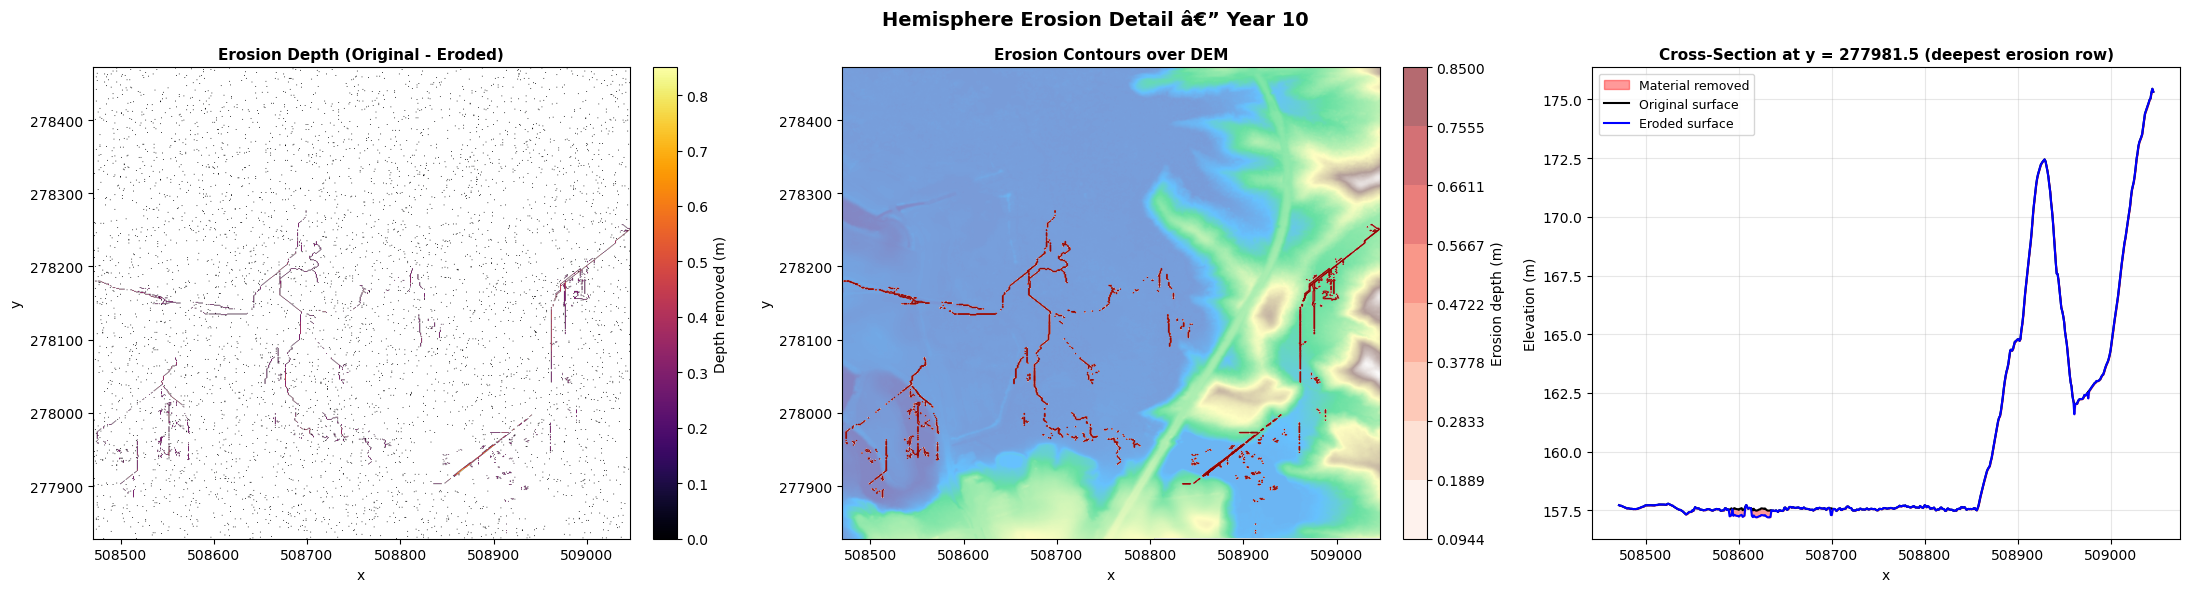


--- Erosion Summary (Year 10) ---
  Max erosion depth:     0.850 m
  Mean erosion (active): 0.113 m
  Cells eroded:          7,290
  Total volume removed:  206.0 m^3
  Active radius cells:   10,433
  R range:               0.284 - 0.555 m


In [14]:
# ========================================================================
# EROSION DIFFERENCE MAP + CROSS-SECTION
# ========================================================================

diff = Z_orig - Z_eroded  # positive = material removed
diff_masked = np.ma.masked_where(diff <= 0, diff)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    f"Hemisphere Erosion Detail â€” Year {_last_year}",
    fontsize=14, fontweight="bold",
)

# Panel 1: Erosion depth map
ax = axes[0]
im = ax.imshow(diff_masked, origin="lower", extent=ext, cmap="inferno",
               aspect="auto")
ax.set_title("Erosion Depth (Original - Eroded)", fontsize=11, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Depth removed (m)", fraction=0.046, pad=0.04)

# Panel 2: Erosion contours over DEM
ax = axes[1]
ax.imshow(Z_orig, origin="lower", extent=ext, cmap="terrain", aspect="auto", alpha=0.6)
ny_d, nx_d = diff.shape
x_lin = np.linspace(ext[0], ext[1], nx_d)
y_lin = np.linspace(ext[2], ext[3], ny_d)
XX, YY = np.meshgrid(x_lin, y_lin)
diff_clean = np.where(np.isfinite(diff), diff, 0.0)
if diff_clean.max() > 0:
    levels = np.linspace(0, float(diff_clean.max()), 10)
    levels = levels[levels > 0]
    if len(levels) > 1:
        cs = ax.contourf(XX, YY, diff_clean, levels=levels, cmap="Reds", alpha=0.6)
        plt.colorbar(cs, ax=ax, label="Erosion depth (m)", fraction=0.046, pad=0.04)
        ax.contour(XX, YY, diff_clean, levels=levels, colors="darkred",
                   linewidths=0.5, alpha=0.7)
ax.set_title("Erosion Contours over DEM", fontsize=11, fontweight="bold")
ax.set_xlabel("x"); ax.set_ylabel("y")

# Panel 3: Cross-section through deepest point
ax = axes[2]
row_sums = np.nansum(diff_clean, axis=1)
deepest_row = int(np.argmax(row_sums))
y_val = ext[2] + deepest_row * _gs
profile_orig = Z_orig[deepest_row, :]
profile_eroded = Z_eroded[deepest_row, :]
x_profile = np.linspace(ext[0], ext[1], len(profile_orig))

ax.fill_between(x_profile, profile_eroded, profile_orig,
                alpha=0.4, color="red", label="Material removed")
ax.plot(x_profile, profile_orig, 'k-', linewidth=1.5, label="Original surface")
ax.plot(x_profile, profile_eroded, 'b-', linewidth=1.5, label="Eroded surface")
ax.set_title(f"Cross-Section at y = {y_val:.1f} (deepest erosion row)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("Elevation (m)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
diff_path = _run_root / f"{stem}_year{_last_year:02d}_erosion_difference.png"
plt.savefig(diff_path, dpi=200, bbox_inches="tight")
print(f"Saved erosion difference figure: {diff_path}")
plt.show()

# Print summary stats
print(f"\n--- Erosion Summary (Year {_last_year}) ---")
print(f"  Max erosion depth:     {float(np.nanmax(diff)):.3f} m")
if (diff > 0).any():
    print(f"  Mean erosion (active): {float(np.nanmean(diff[diff > 0])):.3f} m")
else:
    print(f"  No erosion detected")
print(f"  Cells eroded:          {int((diff > 0).sum()):,}")
print(f"  Total volume removed:  {float(np.nansum(diff) * _gs * _gs):.1f} m^3")
n_r = int((df_volume['radius'] > 0).sum())
print(f"  Active radius cells:   {n_r:,}")
if n_r > 0:
    print(f"  R range:               {float(df_volume['radius'][df_volume['radius']>0].min()):.3f} - {float(df_volume['radius'].max()):.3f} m")

## Cell 15 - Canal Prediction on Real Landscapes

Reconstructs an RGB basemap from the NAIP red, green, and blue bands, then overlays predicted erosion depth so likely canal locations can be read directly against the real landscape.


Saved real-landscape canal prediction figure: C:\Users\jordan.kennedy\Documents\Project\MultiAgent simulation\Datasets\TroyVT\runs\TroyVT_slopes_cropped_troy_vt_Y10_A10_R1\TroyVT_slopes_cropped_troy_vt_year10_canal_prediction_real_landscape.png
Max predicted erosion depth: 0.850 m


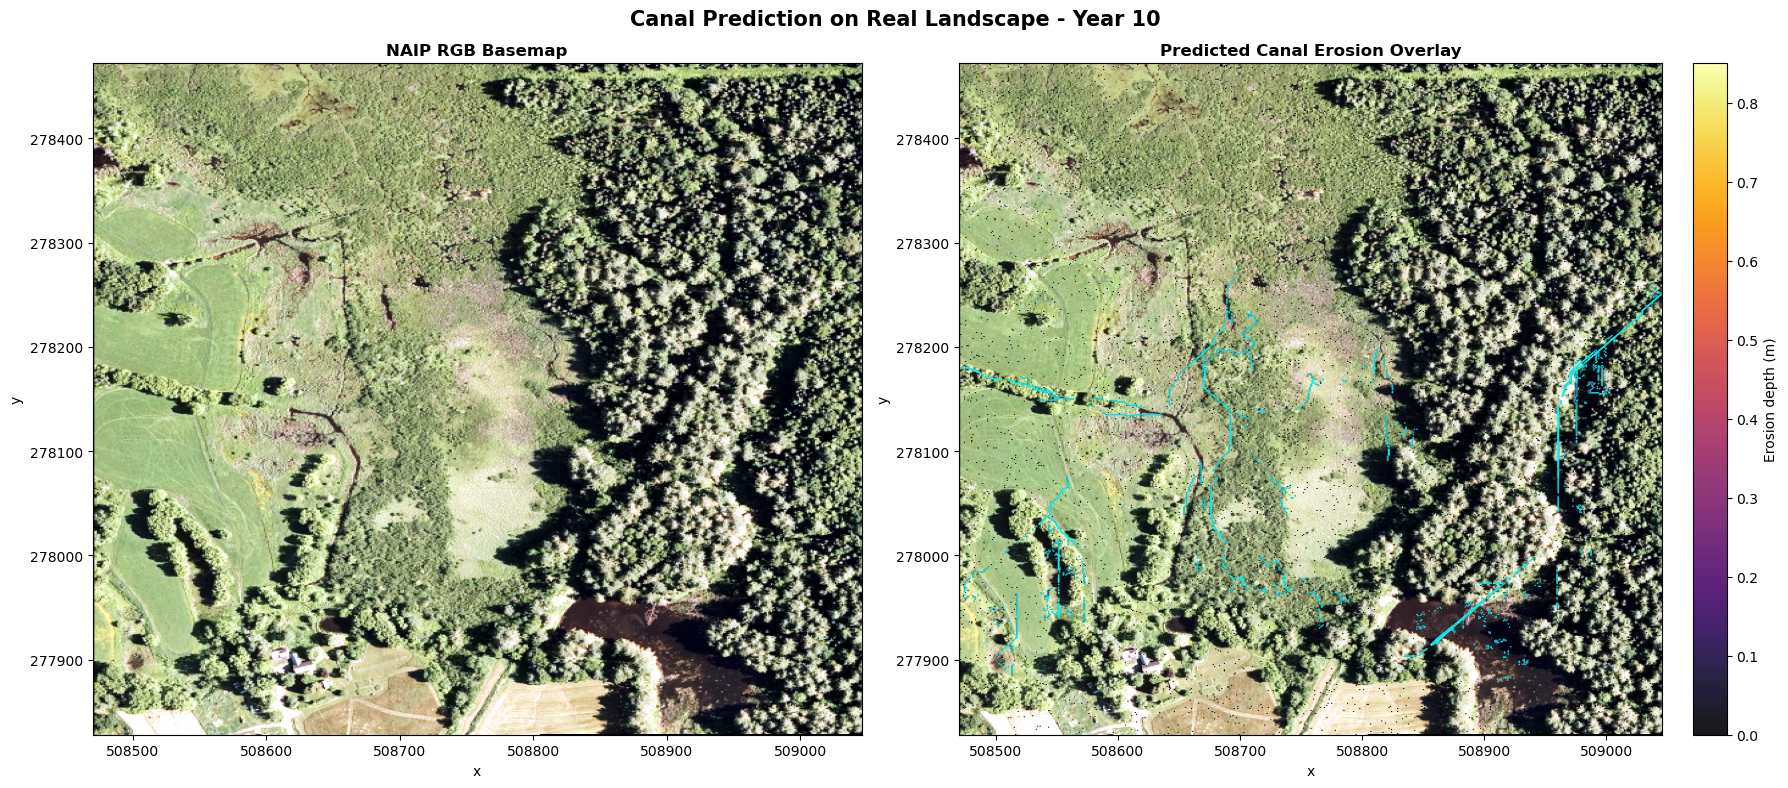

In [15]:
# ========================================================================
# CANAL PREDICTION ON REAL LANDSCAPES (RGB + erosion overlay)
# ========================================================================
last_counter_path, last_updated_path = outputs[-1]
stem = Path(CSV_PATH).stem
_run_root = Path(last_counter_path).parent.parent
_last_year = N_YEARS
erosion_csv = _run_root / "2d_erosion" / f"{stem}_2d_erosion_year{_last_year:02d}.csv"
df_orig_rgb = pd.read_csv(CSV_PATH, low_memory=False)
df_erosion_rgb = pd.read_csv(erosion_csv, low_memory=False)
required_rgb = ["x", "y", "elevation", "naip_R", "naip_G", "naip_B"]
missing_rgb = [c for c in required_rgb if c not in df_orig_rgb.columns]
if missing_rgb:
    raise ValueError(f"Missing NAIP/RGB columns required for overlay: {missing_rgb}")
for _df in [df_orig_rgb, df_erosion_rgb]:
    for c in ["x", "y", "elevation"]:
        if c in _df.columns:
            _df[c] = pd.to_numeric(_df[c], errors="coerce")
for c in ["naip_R", "naip_G", "naip_B"]:
    df_orig_rgb[c] = pd.to_numeric(df_orig_rgb[c], errors="coerce")
_dx_rgb = infer_step(df_orig_rgb["x"].values)
_dy_rgb = infer_step(df_orig_rgb["y"].values)
_gs_rgb = float(np.nanmin([_dx_rgb, _dy_rgb]))
if not np.isfinite(_gs_rgb) or _gs_rgb <= 0:
    _gs_rgb = 1.0
def _grid_one(df, col, gs):
    g, _ = create_grid_FIXED(
        df.dropna(subset=["x", "y", col]),
        grid_spacing=gs, value_cols=(col,),
        agg="mean", return_df_with_indices=True,
    )
    arr = np.asarray(g[col], dtype=float)
    xc, yc = g["x_coords"], g["y_coords"]
    extent = [float(np.min(xc)), float(np.max(xc)), float(np.min(yc)), float(np.max(yc))]
    return arr, extent
R, ext_rgb = _grid_one(df_orig_rgb, "naip_R", _gs_rgb)
G, _ = _grid_one(df_orig_rgb, "naip_G", _gs_rgb)
B, _ = _grid_one(df_orig_rgb, "naip_B", _gs_rgb)
Z_orig_rgb, _ = _grid_one(df_orig_rgb, "elevation", _gs_rgb)
Z_eroded_rgb, _ = _grid_one(df_erosion_rgb, "elevation", _gs_rgb)
def _normalize_band(arr):
    arr = np.asarray(arr, dtype=float)
    finite = np.isfinite(arr)
    out = np.zeros_like(arr, dtype=float)
    if not finite.any():
        return out
    lo, hi = np.nanpercentile(arr[finite], [1, 99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(arr[finite]))
        hi = float(np.nanmax(arr[finite]))
    if not np.isfinite(hi) or hi <= lo:
        out[finite] = 0.5
        return out
    out[finite] = np.clip((arr[finite] - lo) / (hi - lo), 0, 1)
    return out
rgb_img = np.dstack([_normalize_band(R), _normalize_band(G), _normalize_band(B)])
erosion_depth = np.maximum(Z_orig_rgb - Z_eroded_rgb, 0.0)
erosion_masked = np.ma.masked_where(~np.isfinite(erosion_depth) | (erosion_depth <= 0), erosion_depth)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    f"Canal Prediction on Real Landscape - Year {_last_year}",
    fontsize=15, fontweight="bold"
)
ax = axes[0]
ax.imshow(rgb_img, origin="lower", extent=ext_rgb, aspect="auto")
ax.set_title("NAIP RGB Basemap", fontsize=12, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax = axes[1]
ax.imshow(rgb_img, origin="lower", extent=ext_rgb, aspect="auto")
im = ax.imshow(
    erosion_masked, origin="lower", extent=ext_rgb, aspect="auto",
    cmap="inferno", alpha=0.9
)
ax.set_title("Predicted Canal Erosion Overlay", fontsize=12, fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Erosion depth (m)", fraction=0.046, pad=0.04)
if np.isfinite(erosion_depth).any() and float(np.nanmax(erosion_depth)) > 0:
    levels = np.linspace(float(np.nanmax(erosion_depth)) * 0.2, float(np.nanmax(erosion_depth)), 6)
    levels = np.unique(levels[levels > 0])
    if len(levels) > 0:
        ax.contour(
            erosion_depth, levels=levels, origin="lower", extent=ext_rgb,
            colors="cyan", linewidths=0.6, alpha=0.8
        )
plt.tight_layout()
real_landscape_path = _run_root / f"{stem}_year{_last_year:02d}_canal_prediction_real_landscape.png"
plt.savefig(real_landscape_path, dpi=200, bbox_inches="tight")
print(f"Saved real-landscape canal prediction figure: {real_landscape_path}")
print(f"Max predicted erosion depth: {float(np.nanmax(erosion_depth)):.3f} m")
plt.show()
